<a href="https://colab.research.google.com/github/hoang2111/ucl-prediction-neural_network-vs-XGBoost/blob/main/predicting_UCL_neural_network_vs_XGBoost_with_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv('/content/sample_data/champions_league_matches.csv')

df

,date,home_team,away_team,score,venue,referee,home_possession,away_possession,home_shots_on_target,away_shots_on_target,home_saves,away_saves,home_shots_on_target_pct,away_shots_on_target_pct,home_saves_pct,away_saves_pct,result,winner
0,2025-09-16,PSV,Union SG,1–3,Philips Stadion,Anthony Taylor,63%,37%,3 of 10,8 of 18,4 of 8,2 of 3,30.0,44.4,50.0,66.7,Away Win,Union SG
1,2025-09-16,Athletic Club,Arsenal,0–2,San Mamés,Donatas Rumšas,38%,62%,2 of 11,6 of 11,4 of 6,2 of 2,18.2,54.5,66.7,100.0,Away Win,Arsenal
2,2025-09-16,Tottenham Hotspur,Villarreal,1–0,Tottenham Hotspur Stadium,Rade Obrenović,58%,42%,1 of 9,0 of 10,0 of 0,1 of 1,11.1,0.0,NaN,100.0,Home Win,Tottenham Hotspur
3,2025-09-16,Benfica,Qarabağ,2–3,Estádio do Sport Lisboa e Benfica,Erik Lambrechts,53%,47%,3 of 14,5 of 10,2 of 5,1 of 3,21.4,50.0,40.0,33.3,Away Win,Qarabağ
4,2025-09-16,Juventus,Dortmund,4–4,Allianz Stadium,François Letexier,52%,48%,7 of 19,5 of 10,1 of 5,3 of 7,36.8,50.0,20.0,42.9,Draw,Draw
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2026-01-28,Barcelona,FC Copenhagen,NaN,Spotify Camp Nou,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147,2026-01-28,Leverkusen,Villarreal,NaN,BayArena,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,2026-01-28,Paris Saint-Germain,Newcastle United,NaN,Parc des Princes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,2026-01-28,Napoli,Chelsea,NaN,Stadio Diego Armando Maradona,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# removed games that haven't been played from the dataset
df = df.dropna(subset=['winner'])

# categorize a win as 2, a loss as 0 and a draw as 1
df.loc[(df['result'] == 'Away Win'), 'result'] = 0
df.loc[(df['result'] == 'Home Win'), 'result'] = 2
df.loc[(df['result'] == 'Draw'), 'result'] = 1

In [3]:
# convert 'home_shots_on_target', 'home_saves', 'away_saves', 'away_shots_on_target' into fractions
# first I split the column's elements into a list of 2 elements:
df['home_shots_on_target'] = df['home_shots_on_target'].str.split(" of ")
df['away_shots_on_target'] = df['away_shots_on_target'].str.split(" of ")
df['home_saves'] = df['home_saves'].str.split(" of ")
df['away_saves'] = df['away_saves'].str.split(" of ")

In [4]:
# then I extract the first and second elements of those lists, convert them to
# floats, and divide them to create a ratio (e.g., "5 of 10" becomes 0.5)
df['home_shots_on_target'] = df['home_shots_on_target'].str[0].astype(float) / df['home_shots_on_target'].str[1].astype(float)
df['away_shots_on_target'] = df['away_shots_on_target'].str[0].astype(float)  / df['away_shots_on_target'].str[1].astype(float)
df['home_saves'] = df['home_saves'].str[0].astype(float)  / df['home_saves'].str[1].astype(float)
df['away_saves'] = df['away_saves'].str[0].astype(float)  / df['away_saves'].str[1].astype(float)

In [5]:
df = df.dropna(subset=['home_saves'])

In [6]:
df['date'] = pd.to_datetime(df['date'])

# Strip the '%', convert to float, and divide by 100
df['home_possession'] = df['home_possession'].str.rstrip('%').astype('float') / 100
# Strip the '%', convert to float, and divide by 100
df['away_possession'] = df['away_possession'].str.rstrip('%').astype('float') / 100

In [3]:
xg_data = pd.read_csv('/content/sample_data/all_scraped_xg_stats.csv')

xg_data

,Date,Home Team,Home xG,Away xG,Away Team,Delta_xG
0,Sep 18,Sporting,3.90,0.70,Kairat,3.20
1,Sep 18,Man City,2.21,0.22,Napoli,1.99
2,Sep 17,PSG,3.39,0.58,Atalanta,2.81
3,Sep 17,Bayern M.,2.03,0.81,Chelsea,1.22
4,Sep 18,Bruges,3.14,1.50,Monaco,1.64
...,...,...,...,...,...,...
121,Jan 21,Juventus,1.43,1.33,Benfica,0.10
122,Jan 21,Galatasaray,0.46,1.37,Atlético,-0.91
123,Jan 20,Villarreal,1.39,0.95,Ajax,0.44
124,Jan 20,Sporting,0.94,1.38,PSG,-0.44


In [4]:
# helper function to convert the year in xg_data into a datetime object
# to do a merge with df
def format_str(date):
  cur_date = date.split(' ')
  year = '2026' if cur_date[0] == 'Jan' else '2025'

  return f"{date} {year}"

xg_data['Date'] = xg_data['Date'].apply(format_str)
xg_data['Date'] = pd.to_datetime(xg_data['Date'], format='%b %d %Y')

In [5]:
from difflib import get_close_matches

# Simple helper to find the best match in xg_data for a name in df
def find_best_match(name, choices):
    match = get_close_matches(name, choices, n=1, cutoff=0.6)
    return match[0] if match else name

df['home_team'] = df['home_team'].apply(lambda x: find_best_match(x, xg_data['Home Team'].unique()))

TypeError: 'float' object is not iterable

In [6]:
merged_df = df.merge(
    xg_data[['Date', 'Home Team', 'Delta_xG']],
    how='left',
    left_on=['date', 'home_team'],
    right_on=['Date', 'Home Team']
).drop(columns=['Date', 'Home Team'])

ValueError: You are trying to merge on object and datetime64[ns] columns for key 'date'. If you wish to proceed you should use pd.concat

In [11]:
merged_df = merged_df.dropna(subset=['Delta_xG'])
merged_df['result'] = merged_df['result'].astype(int)

In [7]:
# extracting the market values of teams in UEFA Champions League
import pandas as pd
import requests

url = 'https://www.transfermarkt.us/uefa-champions-league/teilnehmer/pokalwettbewerb/CL'

# 1. Define a header to look like a real browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36'
}

# 2. Fetch the page content
response = requests.get(url, headers=headers)

# 3. Pass the raw HTML string into pandas
# Note: read_html returns a list of all tables found on the page
tables = pd.read_html(response.text)

market_values = pd.concat([tables[1], tables[2]], axis=0)

market_values

/tmp/ipython-input-670393204.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,wappen,Club,Club.1,Squad,ø-Age,Market Value,ø-Market Value
0,NaN,Real Madrid,25,26.3,€1.35bn,€54.12m,NaN
1,NaN,Paris Saint-Germain,24,23.9,€1.20bn,€49.90m,NaN
2,NaN,Newcastle United,26,27.9,€709.55m,€27.29m,NaN
3,NaN,Inter Milan,24,29.2,€666.80m,€27.78m,NaN
4,NaN,Atlético de Madrid,23,27.5,€584.00m,€25.39m,NaN
5,NaN,Juventus FC,25,27.2,€560.20m,€22.41m,NaN
6,NaN,Borussia Dortmund,24,26.8,€483.40m,€20.14m,NaN
7,NaN,Bayer 04 Leverkusen,26,26.7,€421.75m,€16.22m,NaN
8,NaN,Atalanta BC,24,27.2,€386.10m,€16.09m,NaN
9,NaN,SL Benfica,28,24.6,€361.50m,€12.91m,NaN


In [13]:
merged_df['home_team'] = merged_df['home_team'].apply(lambda x: find_best_match(x, merged_df['away_team'].unique()))

In [14]:
# match the club names in market values with merged_df
# to do another merge with merged_df
market_values['Club'] = market_values['Club'].apply(lambda x: find_best_match(x, merged_df['away_team'].unique()))

In [15]:
market_values.loc[(market_values['Club'] == 'Ajax Amsterdam'), 'Club'] = 'Ajax'
market_values.loc[(market_values['Club'] == 'Union Saint-Gilloise'), 'Club'] = 'Union SG'
market_values.loc[(market_values['Club'] == 'PSV Eindhoven'), 'Club'] = 'PSV'
market_values.loc[(market_values['Club'] == 'Kairat Almaty'), 'Club'] = 'FC Kairat'

In [16]:
# Merge the market value column (adjust 'Total market value' to the actual column name from your scrape)
merged_df = merged_df.merge(
    market_values[['Club', 'Market Value']],
    left_on='away_team',
    right_on='Club',
    how='left'
).drop(columns=['Club'])

merged_df = merged_df.rename(columns={'Market Value': 'Market Value Away'})

In [17]:
merged_df = merged_df.merge(
    market_values[['Club', 'Market Value']],
    left_on='home_team',
    right_on='Club',
    how='left'
).drop(columns=['Club'])

merged_df = merged_df.rename(columns={'Market Value': 'Market Value Home'})

In [18]:
# convert the market values of each team into numbers
def clean_market_value(value):
    if pd.isna(value): return 0
    value = value.replace('€', '').replace(' ', '')
    if 'bn' in value:
        return float(value.replace('bn', '')) * 1000  # Convert to millions
    elif 'm' in value:
        return float(value.replace('m', ''))
    return 0

merged_df['Market Value Away'] = merged_df['Market Value Away'].apply(clean_market_value)
merged_df['Market Value Home'] = merged_df['Market Value Home'].apply(clean_market_value)

In [19]:
merged_df['Delta_MV'] = merged_df['Market Value Home'] - merged_df['Market Value Away']
merged_df = merged_df.drop(['Market Value Home', 'Market Value Away'], axis=1)

In [20]:
cols = merged_df.select_dtypes(include=['number']).columns.tolist()
cols.remove('result')
cols

['home_possession',
 'away_possession',
 'home_shots_on_target',
 'away_shots_on_target',
 'home_saves',
 'away_saves',
 'home_shots_on_target_pct',
 'away_shots_on_target_pct',
 'home_saves_pct',
 'away_saves_pct',
 'Delta_xG',
 'Delta_MV']

In [21]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the scaler
scaler = MinMaxScaler()

# 2. Select the numerical columns to normalize
cols_to_scale = cols

# 3. Fit and transform the data
merged_df[cols_to_scale] = scaler.fit_transform(merged_df[cols_to_scale])

In [22]:
from sklearn.model_selection import train_test_split, cross_val_score

# First: 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    merged_df[cols_to_scale],
    merged_df['result'],
    test_size=0.30,
    random_state=42
)

# Second: Split the 30% Temp into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

Neural Networks

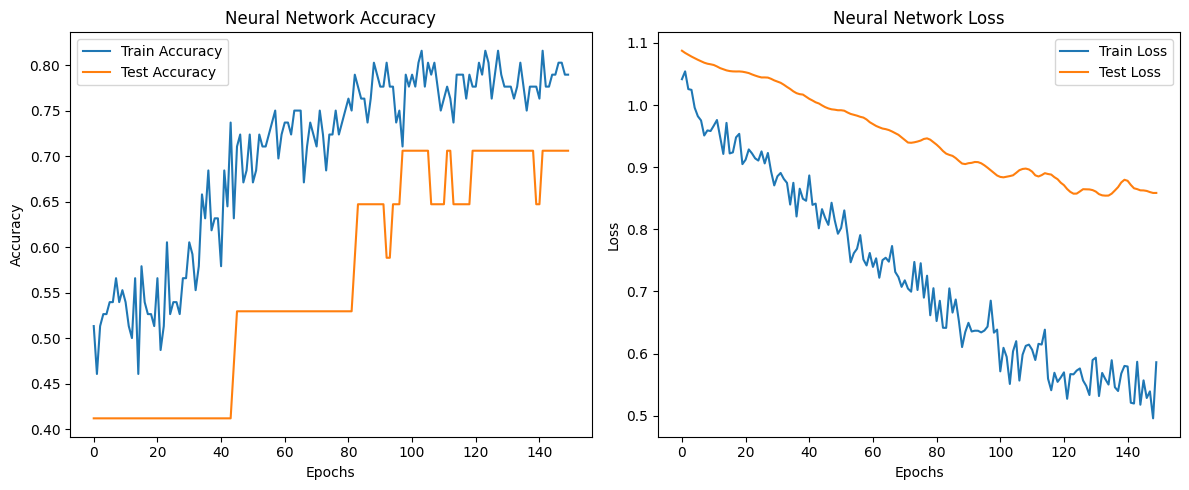

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7059 - loss: 0.8586


In [23]:
import tensorflow as tf
import matplotlib.pyplot as plt

model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Add dropout to stop the 30% failure
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax') # Only 3 nodes!
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train, y_train,
                    epochs=150,
                    validation_data=(X_test, y_test),
                    verbose=0) # Set verbose to 0 to keep output clean

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Neural Network Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Neural Network Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
loss, accuracy = model.evaluate(X_test, y_test)

XGBoost

In [25]:
import xgboost as xgb
import numpy as np

from sklearn.metrics import accuracy_score
# Initialize the Classifier
# objective='multi:softmax' is for multi-class classification
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softmax',
    num_class=3,
    random_state=42
)
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5)
print(f"XGBoost CV Mean Accuracy: {np.mean(cv_scores):.2%}")

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
# Train the model
# We use the numeric-only X data we prepared earlier
xgb_model.fit(X_train, y_train)

# Make predictions
preds = xgb_model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, preds)
print(f"XGBoost Accuracy: {accuracy:.2f}")

XGBoost CV Mean Accuracy: 69.67%
XGBoost Accuracy: 0.65


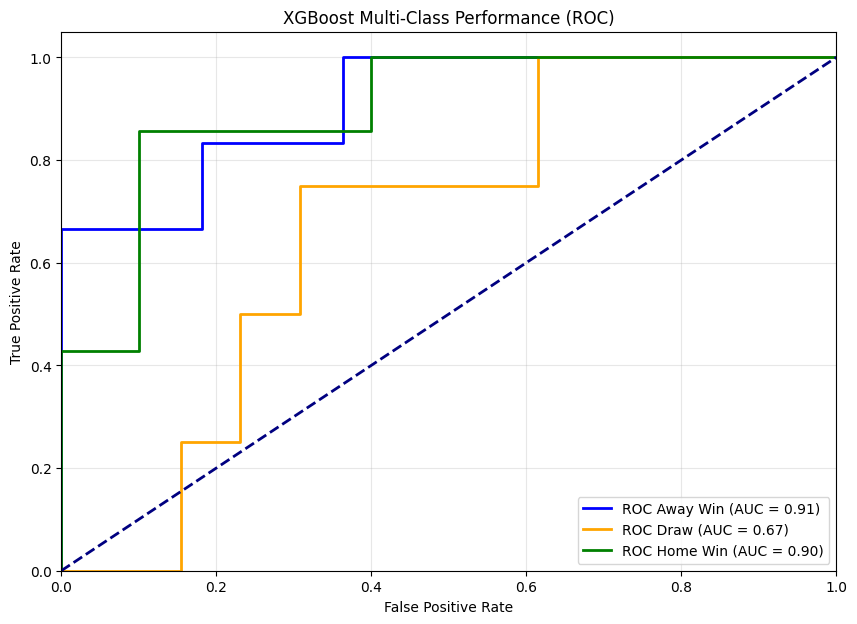

In [26]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
xgb_probs = xgb_model.predict_proba(X_test)

plt.figure(figsize=(10, 7))
colors = ['blue', 'orange', 'green']
outcomes = ['Away Win', 'Draw', 'Home Win']

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], xgb_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC {outcomes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost Multi-Class Performance (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()